# Notebook 04 - Escalamiento y PCA

En este notebook se aplica escalamiento y reducción de dimensionalidad
mediante Análisis de Componentes Principales (PCA) sobre las variables
numéricas del dataset limpio. Se documentan las variables utilizadas,
el escalamiento aplicado, la varianza explicada por cada componente
y la interpretación de los loadings obtenidos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('../data/processed/streaming_users_clean.csv')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Dataset cargado: 7884 filas, 8 columnas


## Selección de variables

Para aplicar PCA se requieren variables numéricas continuas.
El dataset cuenta con tres variables de este tipo:

- `age`: edad del usuario
- `monthly_watch_time_mins`: tiempo mensual de visualización en minutos
- `customer_support_tickets`: cantidad de tickets de soporte generados

Las variables categóricas (país, plan, género) se excluyen porque
PCA requiere datos numéricos. Se revisan las escalas antes de escalar
para justificar el uso de StandardScaler.

In [2]:
# Revisamos las escalas de las variables antes de escalar
# Si hay diferencias grandes entre rangos, el escalado no es opcional
variables = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = df[variables]

print("=== Estadísticas descriptivas ===")
print(X.describe().round(2))
print()
print("=== Varianza original por variable ===")
print(X.var().round(2))

=== Estadísticas descriptivas ===
           age  monthly_watch_time_mins  customer_support_tickets
count  7884.00                  7884.00                   7884.00
mean     33.53                   791.10                      0.83
std      11.77                   446.30                      0.94
min       0.00                     0.00                      0.00
25%      25.00                   498.55                      0.00
50%      33.00                   760.80                      1.00
75%      42.00                  1038.38                      1.00
max      80.00                  2704.70                      4.00

=== Varianza original por variable ===
age                            138.47
monthly_watch_time_mins     199185.93
customer_support_tickets         0.88
dtype: float64


## Escalamiento previo: condición no negociable

Las variables presentan escalas muy distintas entre sí:
`monthly_watch_time_mins` tiene valores de hasta 2704 minutos,
mientras que `customer_support_tickets` varía entre 0 y 4.
Sin escalar, `monthly_watch_time_mins` dominaría artificialmente
la dirección de máxima varianza por razones puramente numéricas,
no por relevancia real.

Se aplica estandarización Z-score (StandardScaler) que lleva todas
las variables a media 0 y desviación estándar 1, poniéndolas en
igualdad de condiciones para el PCA.

In [3]:
# Aplicamos StandardScaler: lleva todas las variables a media 0 y std 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificamos que la varianza quedó uniforme
X_scaled_df = pd.DataFrame(X_scaled, columns=variables)
print("=== Varianza antes del escalamiento ===")
print(X.var().round(4))
print()
print("=== Varianza después del escalamiento ===")
print(X_scaled_df.var().round(4))

=== Varianza antes del escalamiento ===
age                            138.4676
monthly_watch_time_mins     199185.9285
customer_support_tickets         0.8750
dtype: float64

=== Varianza después del escalamiento ===
age                         1.0001
monthly_watch_time_mins     1.0001
customer_support_tickets    1.0001
dtype: float64


## PCA sobre todas las componentes posibles

Primero aplicamos PCA sin restringir el número de componentes
para analizar cuánta varianza explica cada una y decidir
cuántas son suficientes usando el umbral de varianza acumulada.
No se elige el número de componentes por defecto ni de forma
arbitraria: la decisión surge de los datos.

In [4]:
# PCA completo: tantas componentes como variables
pca_full = PCA()
pca_full.fit(X_scaled)

varianza = pca_full.explained_variance_ratio_
acumulada = 0

print("=== Varianza explicada por componente ===")
for i in range(len(varianza)):
    acumulada += varianza[i]
    print(
        f"PC{i+1}: {varianza[i]*100:.2f}% | "
        f"Varianza acumulada: {acumulada*100:.2f}%"
    )

=== Varianza explicada por componente ===
PC1: 33.75% | Varianza acumulada: 33.75%
PC2: 33.22% | Varianza acumulada: 66.97%
PC3: 33.03% | Varianza acumulada: 100.00%


### Visualización 1 - Scree plot: varianza explicada por componente

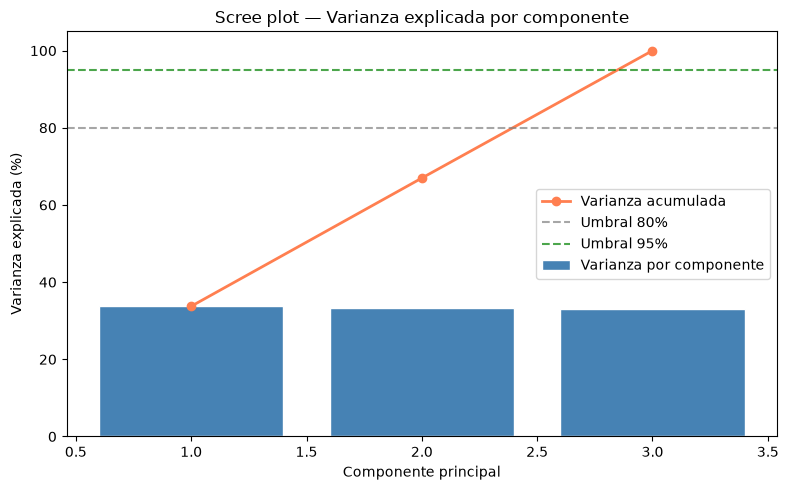

In [5]:
varianza_pct = pca_full.explained_variance_ratio_ * 100
acumulada_pct = varianza_pct.cumsum()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, len(varianza_pct)+1), varianza_pct,
       color='steelblue', edgecolor='white', label='Varianza por componente')
ax.plot(range(1, len(varianza_pct)+1), acumulada_pct,
        'o-', color='coral', linewidth=2, label='Varianza acumulada')
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='Umbral 80%')
ax.axhline(y=95, color='green', linestyle='--', alpha=0.7, label='Umbral 95%')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Varianza explicada (%)')
ax.set_title('Scree plot — Varianza explicada por componente')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** La varianza se distribuye de forma casi uniforme
entre los tres componentes (≈33% cada uno). Esto indica que las tres
variables numéricas aportan información independiente y no redundante
entre sí, lo cual es coherente con las bajas correlaciones observadas
en el EDA. Para superar el umbral del 80% de varianza acumulada
se necesitan las tres componentes, lo que confirma que no es posible
reducir dimensiones sin pérdida significativa de información en este dataset.
Se proyecta igual a 2 componentes con fines de visualización exploratoria,
reconociendo que estos dos componentes explican aproximadamente el 67%
de la varianza total.

## Proyección y análisis de loadings

Se proyectan los datos sobre las dos primeras componentes para
visualización exploratoria. Se analizan los loadings para entender
qué variables dominan cada componente.

In [6]:
# Proyectamos a 2 componentes para visualización
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# Loadings: cuánto aporta cada variable original a PC1 y PC2
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=variables,
    columns=['PC1', 'PC2']
)
print("=== Loadings (contribución de cada variable) ===")
print(loadings.round(3))

=== Loadings (contribución de cada variable) ===
                            PC1    PC2
age                       0.617 -0.400
monthly_watch_time_mins   0.461  0.882
customer_support_tickets  0.638 -0.250


### Visualización 2 - Proyección de usuarios en PC1 y PC2

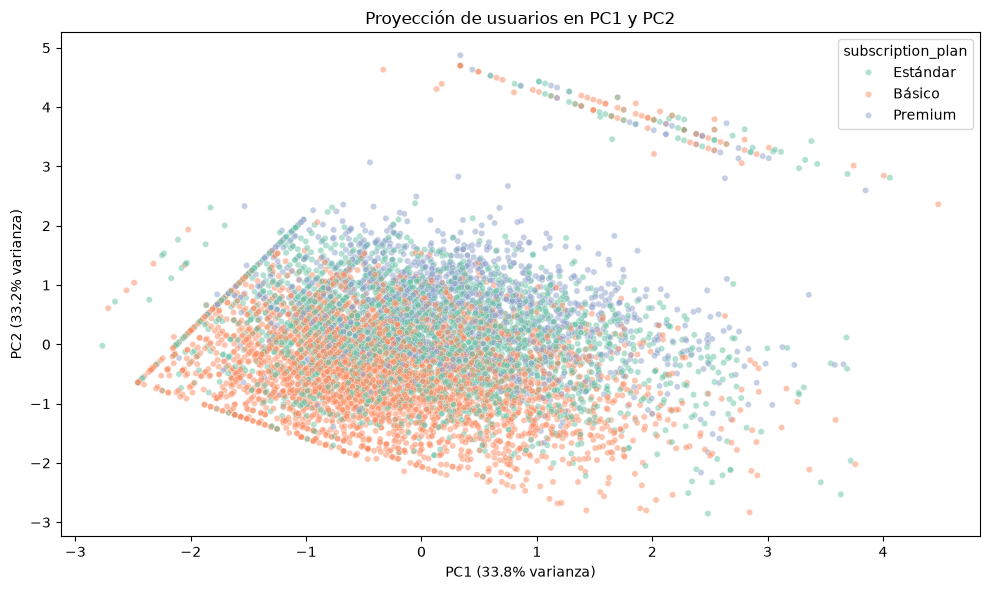

In [7]:
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['subscription_plan'] = df['subscription_plan'].values

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2',
    hue='subscription_plan', palette='Set2',
    alpha=0.5, s=20, ax=ax
)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.set_title('Proyección de usuarios en PC1 y PC2')
plt.tight_layout()
plt.show()

## Interpretación de las componentes

Los componentes se interpretan a partir de sus loadings,
no del número en sí. El analista asigna sentido según el contexto.

**PC1** recibe contribuciones similares de las tres variables.
La variable con mayor peso es `customer_support_tickets`,
lo que sugiere que PC1 resume un perfil general del usuario
que integra nivel de incidencias, consumo y edad.

**PC2** opone `age` contra `monthly_watch_time_mins`:
captura la diferencia entre usuarios mayores con menor tiempo
de consumo y usuarios jóvenes con mayor tiempo de consumo.

**Limitación importante:** con solo 3 variables numéricas,
la varianza se distribuye uniformemente entre los 3 componentes
(≈33% cada uno). Esto indica que las variables no están
correlacionadas entre sí y que PCA no logra una reducción
de dimensionalidad significativa en este dataset.
Para superar el 80% de varianza acumulada se necesitan
las 3 componentes originales.